# V2 统一建模前数据探查

本 Notebook 只物化 Train 与 Selection。全量数据仅做机械完整性核验；所有统计规则由 Train 学习，Selection 负责验证。最终 Test 不在本 Notebook 中加载或展示。

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'configs' / 'experiment.yaml').is_file()
)
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
from credit_risk.development import load_development_data
from credit_risk.profiling import run_development_profile

print('Project root:', PROJECT_ROOT)

Project root: /Users/ganlu/Desktop/home-credit-risk-english


In [2]:
development = load_development_data(PROJECT_ROOT)
assert not hasattr(development, 'X_test')
assert not hasattr(development, 'y_test')
display(development.overview.to_frame('value'))
display(development.split_overview)
print('公共加工后特征数:', len(development.feature_columns))
print('数据SHA256:', development.data_sha256)
print('切分SHA256:', development.split_sha256)

,value
rows,307511.0
columns,122.0
features,120.0
bad_n,24825.0
bad_rate,0.080729
unique_id,307511.0
duplicate_rows,0.0
infinite_numeric_values,0.0
sha256,52e96b895b1112e1c853f670e58372719c8441c5ed1c57...
source,/Users/ganlu/Desktop/home-credit-risk-english/...


,sample,n,bad_rate
0,Train,215257,0.080727
1,Selection,46127,0.080734
2,Test (sealed),46127,NaN


公共加工后特征数: 126
数据SHA256: 52e96b895b1112e1c853f670e58372719c8441c5ed1c57ac2f7fad559d784f5f
切分SHA256: 4ae4ceee661ba8c210fa0a1cf950448799a0aef468659e6d2590c1bb4e8a3835


In [3]:
profile = run_development_profile(development)
display(profile.decisions['recommended_action'].value_counts().to_frame('feature_n'))
display(profile.missing.loc[profile.missing.missing_n > 0].head(30))
display(profile.category_summary.head(30))
display(profile.psi_summary.head(30))
display(profile.numeric_anomalies.head(30))
print('候选变量:', len(profile.candidate_features))
print('复核变量:', len(profile.review_features))
print('输出目录:', profile.run_directory)

,feature_n
recommended_action,
keep_candidate,85
review,41


,feature,dtype,missing_n,missing_rate,bad_rate_missing,bad_rate_nonmissing,bad_rate_gap_missing_minus_nonmissing,abs_bad_rate_gap,selection_missing_rate,selection_minus_train_missing_rate
0,COMMONAREA_AVG,float32,150300,0.698235,0.085602,0.069446,0.016156,0.016156,0.699222,0.000987
1,COMMONAREA_MODE,float32,150300,0.698235,0.085602,0.069446,0.016156,0.016156,0.699222,0.000987
2,COMMONAREA_MEDI,float32,150300,0.698235,0.085602,0.069446,0.016156,0.016156,0.699222,0.000987
3,NONLIVINGAPARTMENTS_AVG,float32,149354,0.693840,0.085649,0.069572,0.016077,0.016077,0.695038,0.001197
4,NONLIVINGAPARTMENTS_MODE,float32,149354,0.693840,0.085649,0.069572,0.016077,0.016077,0.695038,0.001197
5,NONLIVINGAPARTMENTS_MEDI,float32,149354,0.693840,0.085649,0.069572,0.016077,0.016077,0.695038,0.001197
6,FONDKAPREMONT_MODE,str,147099,0.683365,0.085908,0.069544,0.016364,0.016364,0.684458,0.001094
7,LIVINGAPARTMENTS_AVG,float32,147049,0.683132,0.085944,0.069479,0.016465,0.016465,0.684458,0.001326
8,LIVINGAPARTMENTS_MODE,float32,147049,0.683132,0.085944,0.069479,0.016465,0.016465,0.684458,0.001326
9,LIVINGAPARTMENTS_MEDI,float32,147049,0.683132,0.085944,0.069479,0.016465,0.016465,0.684458,0.001326


,feature,category_kind,levels_nonmissing_train,missing_rate_train,top_level_share_train,rare_level_n,rare_sample_share_train,selection_unseen_level_n,selection_unseen_sample_rate
0,NAME_CONTRACT_TYPE,physical_categorical,2,0.000000,0.904384,0,0.000000,0,0.0
1,FLAG_OWN_CAR,physical_categorical,2,0.000000,0.660076,0,0.000000,0,0.0
2,FLAG_OWN_REALTY,physical_categorical,2,0.000000,0.694110,0,0.000000,0,0.0
3,NAME_TYPE_SUITE,physical_categorical,7,0.004186,0.808750,1,0.000920,0,0.0
4,NAME_INCOME_TYPE,physical_categorical,8,0.000000,0.515588,4,0.000172,0,0.0
5,NAME_EDUCATION_TYPE,physical_categorical,5,0.000000,0.710746,1,0.000483,0,0.0
6,NAME_FAMILY_STATUS,physical_categorical,6,0.000000,0.638572,1,0.000005,0,0.0
7,NAME_HOUSING_TYPE,physical_categorical,6,0.000000,0.888050,0,0.000000,0,0.0
8,FLAG_MOBIL,low_card_numeric_candidate,2,0.000000,0.999995,1,0.000005,0,0.0
9,FLAG_EMP_PHONE,low_card_numeric_candidate,2,0.000000,0.819908,0,0.000000,0,0.0


,feature,psi_type,psi_selection,psi_flag
0,ORGANIZATION_TYPE,categorical,0.001352,stable
1,OCCUPATION_TYPE,categorical,0.000698,stable
2,PHONE_CHANGE_YEARS,numeric,0.000447,stable
3,EMPLOYED_YEARS,numeric,0.000400,stable
4,EXT_SOURCE_3,numeric,0.000397,stable
5,COMMONAREA_AVG,numeric,0.000381,stable
6,NONLIVINGAREA_MEDI,numeric,0.000349,stable
7,EMPLOYED_AGE_RATIO,numeric,0.000334,stable
8,YEARS_BEGINEXPLUATATION_AVG,numeric,0.000323,stable
9,YEARS_BEGINEXPLUATATION_MODE,numeric,0.000321,stable


,feature,valid_n,inf_n,min,q005,median,q995,max,iqr_low,iqr_high,iqr_outlier_rate,selection_outside_train_minmax_rate,selection_outside_train_q005_q995_rate,known_special_counts
0,REGION_RATING_CLIENT,215257,0,1.000000,1.000000,2.000000,3.000000e+00,3.000000e+00,2.000000,2.000000e+00,0.262063,0.000000,0.000000,{}
1,REGION_RATING_CLIENT_W_CITY,215257,0,1.000000,1.000000,2.000000,3.000000e+00,3.000000e+00,2.000000,2.000000e+00,0.254082,0.000000,0.000000,{}
2,REG_CITY_NOT_WORK_CITY,215257,0,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,0.000000,0.000000e+00,0.230236,0.000000,0.000000,{}
3,FLAG_WORK_PHONE,215257,0,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,0.000000,0.000000e+00,0.199069,0.000000,0.000000,{}
4,FLAG_EMP_PHONE,215257,0,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,0.180092,0.000000,0.000000,{}
5,EMPLOYED_SPECIAL_FLAG,215257,0,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,0.000000,0.000000e+00,0.180045,0.000000,0.000000,{}
6,LIVE_CITY_NOT_WORK_CITY,215257,0,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,0.000000,0.000000e+00,0.179966,0.000000,0.000000,{}
7,AMT_REQ_CREDIT_BUREAU_QRT,186176,0,0.000000,0.000000,0.000000,3.000000e+00,1.900000e+01,0.000000,0.000000e+00,0.163902,0.000000,0.001821,{}
8,AMT_REQ_CREDIT_BUREAU_MON,186176,0,0.000000,0.000000,0.000000,6.000000e+00,2.700000e+01,0.000000,0.000000e+00,0.141677,0.000000,0.004423,{}
9,DEF_30_CNT_SOCIAL_CIRCLE,214543,0,0.000000,0.000000,0.000000,2.000000e+00,3.400000e+01,0.000000,0.000000e+00,0.114073,0.000000,0.005095,{}


候选变量: 126
复核变量: 41
输出目录: /Users/ganlu/Desktop/home-credit-risk-english/artifacts/data_profile/20260831T023851_361754Z


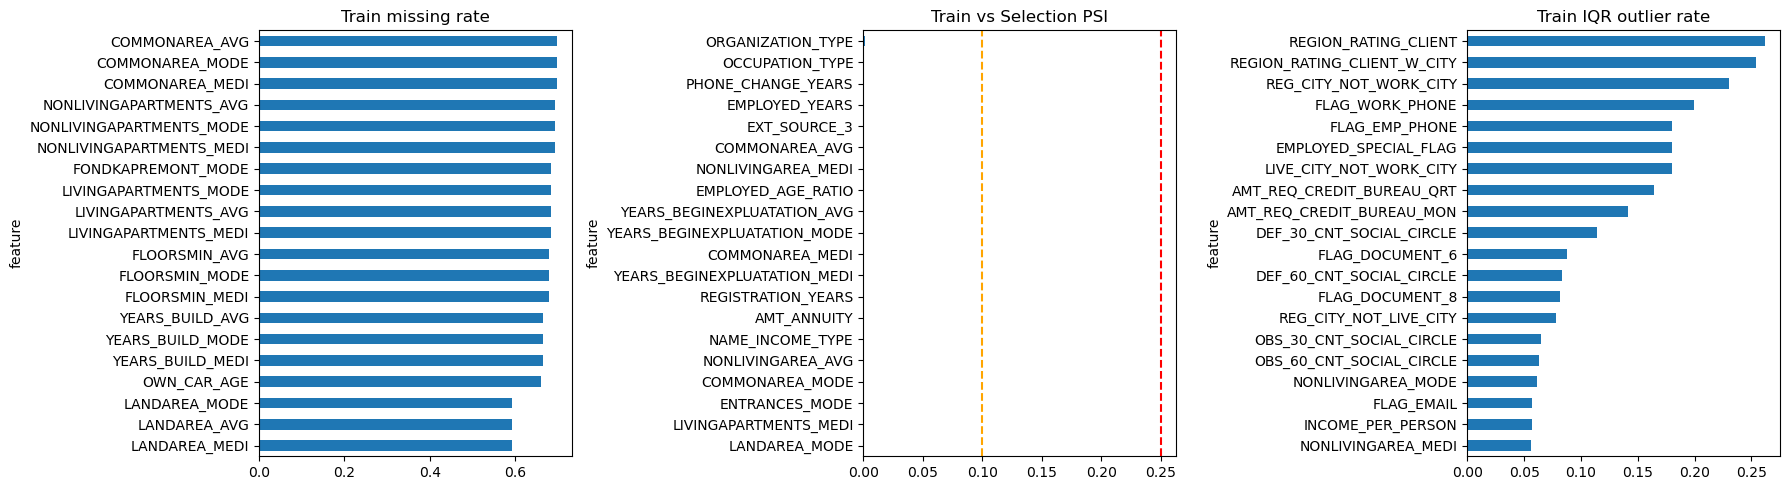

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
profile.missing.head(20).sort_values('missing_rate').plot.barh(
    x='feature', y='missing_rate', ax=axes[0], legend=False, title='Train missing rate'
)
profile.psi_summary.head(20).sort_values('psi_selection').plot.barh(
    x='feature', y='psi_selection', ax=axes[1], legend=False, title='Train vs Selection PSI'
)
profile.numeric_anomalies.head(20).sort_values('iqr_outlier_rate').plot.barh(
    x='feature', y='iqr_outlier_rate', ax=axes[2], legend=False, title='Train IQR outlier rate'
)
axes[1].axvline(0.10, color='orange', linestyle='--')
axes[1].axvline(0.25, color='red', linestyle='--')
plt.tight_layout()
plt.show()

## 交接

正式模型读取同一份配置和切分指纹。高缺失、近常量、PSI、异常值和未见类别只进入复核清单，不在公共层自动删除、填补或截尾。Test 诊断将在全部规定模型锁定后由最终比较 Notebook 生成。